# S/F Proximity Effect

The **proximity effect** in superconductor/ferromagnet (S/F) heterostructures
describes how Cooper pairs leak from S into F. The exchange field in the
ferromagnet causes the pair amplitude to oscillate and decay — an FFLO-like
effect that is the origin of many striking phenomena in S/F physics, including
$T_c$ oscillations, $\pi$-junctions, and re-entrant superconductivity.

## FFLO-Like Oscillation in the Ferromagnet

In a normal metal ($E_{\text{ex}} = 0$), Cooper pairs decay monotonically
into the metal over the thermal length $\xi_N = \sqrt{\hbar D / 2\pi k_B T}$.

In a ferromagnet, the exchange field $E_{\text{ex}}$ splits the Fermi surface
for spin-up and spin-down electrons. A singlet pair entering F acquires a
finite center-of-mass momentum, causing it to **oscillate** while decaying:

$$
F(x) = F_0 \exp\!\left(-\frac{x}{\xi_F}\right)
\cos\!\left(\frac{x}{\xi_F}\right)
$$

The characteristic length scale is the **ferromagnetic coherence length**:

$$
\xi_F = \sqrt{\frac{\hbar D_F}{E_{\text{ex}}}}
$$

| Material | $E_{\text{ex}}$ (meV) | $\xi_F$ (nm) | Character |
|----------|----------------------:|-------------:|----------|
| PdNi     | 2–5                   | 5–10         | Weak FM  |
| CuNi     | 5–15                  | 3–5          | Weak FM  |
| Ni       | 150                   | 1.2          | Strong FM |
| Fe       | 256                   | 0.7          | Strong FM |
| Co       | 300                   | 0.6          | Strong FM |

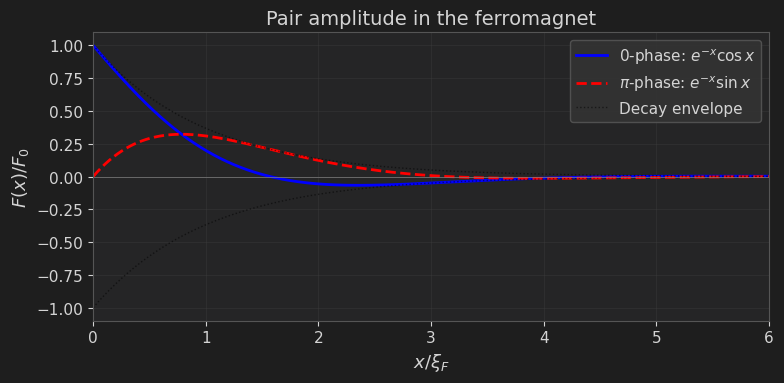

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import supermag
supermag.apply_theme("dark")

x = np.linspace(0, 6, 500)  # in units of xi_F

# 0-phase (cosine) and π-phase (sine) pair amplitudes
F_zero = np.exp(-x) * np.cos(x)
F_pi   = np.exp(-x) * np.sin(x)
envelope = np.exp(-x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, F_zero, 'b-', linewidth=2, label=r'0-phase: $e^{-x}\cos x$')
ax.plot(x, F_pi, 'r--', linewidth=2, label=r'$\pi$-phase: $e^{-x}\sin x$')
ax.plot(x, envelope, 'k:', linewidth=1, alpha=0.5, label='Decay envelope')
ax.plot(x, -envelope, 'k:', linewidth=1, alpha=0.5)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel(r'$x / \xi_F$', fontsize=13)
ax.set_ylabel(r'$F(x) / F_0$', fontsize=13)
ax.set_title('Pair amplitude in the ferromagnet', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, 6)
fig.tight_layout()
plt.show()

### SUPERMag Pair Amplitude

The `supermag.pair_amplitude()` function provides the same FFLO-like
pair-amplitude profile via the C++ composable path.  Below we compare
0-phase and π-phase profiles for several ferromagnet coherence lengths.

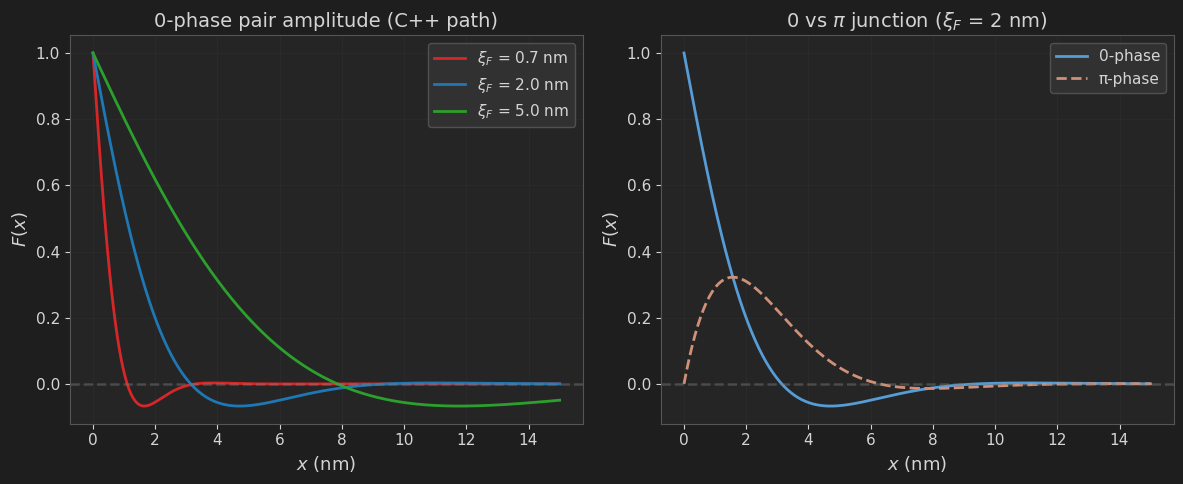

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import supermag

d_F = 15.0  # nm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: 0-phase for several ξ_F values
for xi_F, col in [(0.7, '#d62728'), (2.0, '#1f77b4'), (5.0, '#2ca02c')]:
    x, F = supermag.pair_amplitude(d_F=d_F, xi_F=xi_F, phase="zero")
    axes[0].plot(x, F, color=col, lw=2, label=rf'$\xi_F$ = {xi_F} nm')

axes[0].axhline(0, ls='--', color='grey', alpha=0.4)
axes[0].set_xlabel('$x$ (nm)', fontsize=13)
axes[0].set_ylabel('$F(x)$', fontsize=13)
axes[0].set_title('0-phase pair amplitude (C++ path)', fontsize=14)
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

# Right: 0 vs π comparison
for phase, ls, label in [("zero", '-', '0-phase'), ("pi", '--', 'π-phase')]:
    x, F = supermag.pair_amplitude(d_F=d_F, xi_F=2.0, phase=phase)
    axes[1].plot(x, F, ls=ls, lw=2, label=label)

axes[1].axhline(0, ls='--', color='grey', alpha=0.4)
axes[1].set_xlabel('$x$ (nm)', fontsize=13)
axes[1].set_ylabel('$F(x)$', fontsize=13)
axes[1].set_title(r'0 vs $\pi$ junction ($\xi_F$ = 2 nm)', fontsize=14)
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

### Deriving $\xi_F$

The ferromagnetic coherence length arises from the exchange-split dispersion.
A singlet Cooper pair entering F consists of a spin-up electron with Fermi
momentum $k_{F\uparrow}$ and a spin-down electron with $k_{F\downarrow}$.
The exchange field shifts the bands:

$$
k_{F\uparrow,\downarrow} = k_F \pm \frac{E_{\text{ex}}}{\hbar v_F}
$$

The pair acquires center-of-mass momentum $Q = k_{F\uparrow} - k_{F\downarrow}
= 2 E_{\text{ex}} / (\hbar v_F)$, producing spatial oscillations at
wavelength $\lambda = 2\pi/Q$. In the diffusive limit, the relevant
length scale is set by the diffusion equation:

$$
\xi_F = \sqrt{\frac{\hbar D_F}{E_{\text{ex}}}}
$$

where $D_F$ is the electronic diffusion constant in the ferromagnet.
For strong ferromagnets ($E_{\text{ex}} \sim 100{-}300$ meV),
$\xi_F \sim 0.5{-}2$ nm — a few atomic layers.

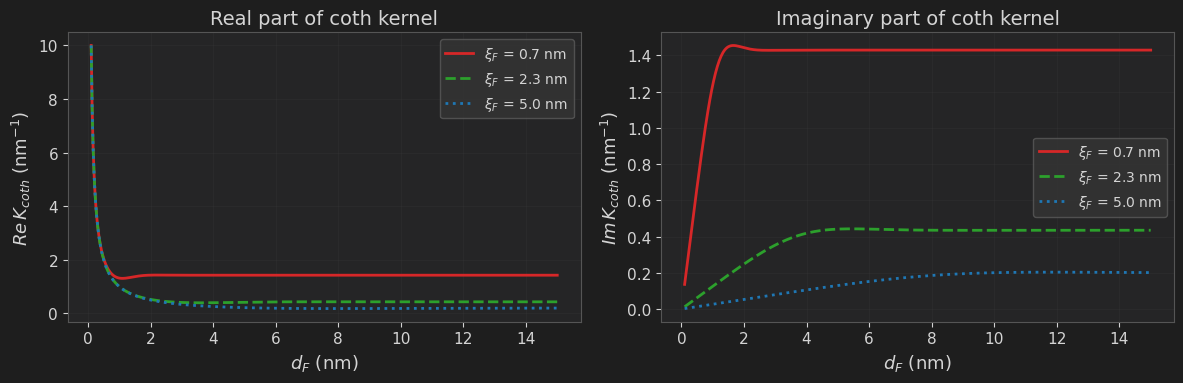

In [3]:
# Proximity kernels: visualize real and imaginary parts
import numpy as np
import matplotlib.pyplot as plt

d_F = np.linspace(0.1, 15, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for xi_F, color, ls in [(0.7, '#d62728', '-'), (2.3, '#2ca02c', '--'), (5.0, '#1f77b4', ':')]:
    q = (1 + 1j) / xi_F
    K_coth = q * np.cosh(q * d_F) / np.sinh(q * d_F)
    K_tanh = q * np.sinh(q * d_F) / np.cosh(q * d_F)
    axes[0].plot(d_F, K_coth.real, color=color, ls=ls, lw=2,
                 label=rf'$\xi_F$ = {xi_F} nm')
    axes[1].plot(d_F, K_coth.imag, color=color, ls=ls, lw=2,
                 label=rf'$\xi_F$ = {xi_F} nm')

for ax, part in zip(axes, ['Re', 'Im']):
    ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
    ax.set_ylabel(rf'${part}\, K_{{coth}}$ (nm$^{{-1}}$)', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].set_title('Real part of coth kernel', fontsize=14)
axes[1].set_title('Imaginary part of coth kernel', fontsize=14)
fig.tight_layout()
plt.show()

## Critical Temperature Suppression

The leakage of Cooper pairs from S into F weakens superconductivity in the
S layer, suppressing $T_c$. For an S/F bilayer, $T_c(d_F)$ oscillates
as a function of the ferromagnet thickness $d_F$, reflecting the
constructive/destructive interference of the oscillating pair amplitude
reflected back into S.

### Single-Mode Approximation (Buzdin, 1982)

In the simplest approximation:

$$
T_c(d_F) \approx T_{c0} \left[ 1 - \frac{\xi_S}{d_S}
\operatorname{Re}\!\left(
\frac{1 - e^{-2\kappa_F d_F}}{\kappa_F \xi_S}
\right) \right]
$$

with complex wavevector $\kappa_F = (1+i)/\xi_F$.

### Digamma Self-Consistency Equation

The rigorous formulation uses the digamma function $\psi(z)$ to sum over
Matsubara frequencies. The $T_c$ equation for an S/F bilayer is:

$$
\ln\!\left(\frac{T_{c0}}{T_c}\right)
= \operatorname{Re}\!\left[
\psi\!\left(\frac{1}{2} + \frac{\gamma\, K(T_c)\, T_{c0}}{2\pi T_c}
+ \lambda_{\text{dep}}\right)
- \psi\!\left(\frac{1}{2}\right)
\right]
$$

where:
- $\psi(z)$ is the digamma function (logarithmic derivative of $\Gamma$)
- $\gamma = \xi_S / d_S$ is the S-layer transparency parameter
- $K(T_c)$ is the proximity kernel (depends on geometry and phase)
- $\lambda_{\text{dep}}$ collects pair-breaking contributions (orbital, spin-orbit, etc.)

#### Proximity Kernels

The kernel $K$ encodes how the ferromagnet feeds back into the S layer.
With complex wavevector $q = (1+i)/\xi_F$:

| Phase | Kernel | Formula |
|-------|--------|---------|
| 0     | coth   | $K = q\, \coth(q\, d_F) / (1 + \gamma_B\, q\, \coth(q\, d_F))$ |
| $\pi$ | tanh   | $K = q\, \tanh(q\, d_F) / (1 + \gamma_B\, q\, \tanh(q\, d_F))$ |

The boundary resistance parameter $\gamma_B$ accounts for interface transparency.

### The Fominov Model (PRB 66, 014507, 2002)

Fominov, Chtchelkatchev & Golubov extended the theory to include:
- Finite interface resistance ($\gamma_B \neq 0$)
- Self-consistent treatment of both S and F layers
- Arbitrary F-layer thickness

Their equation modifies the effective pair-breaking parameter:

$$
\alpha_{\text{eff}} = \frac{\gamma\, K}{1 + \gamma_B\, K}
$$

This model is essential for quantitative comparison with experiment,
particularly for weak ferromagnets with $\gamma_B \sim 0.1{-}1.0$.

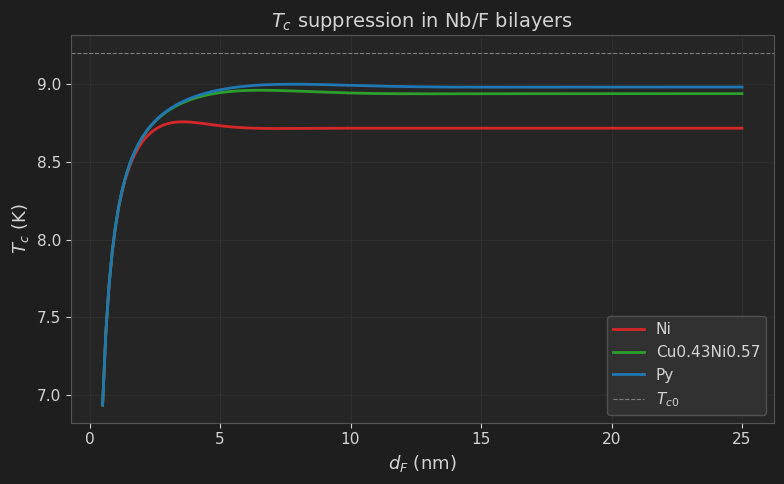

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import supermag

nb = supermag.get_material("Nb")
d_F = np.linspace(0.5, 25.0, 200)

fig, ax = plt.subplots(figsize=(8, 5))

# Compare different ferromagnets
for fm_name, color in [("Ni", "#d62728"), ("Cu0.43Ni0.57", "#2ca02c"), ("Py", "#1f77b4")]:
    fm = supermag.get_material(fm_name)
    Tc = supermag.critical_temperature(
        Tc0=nb["Tc"], d_S=50.0, d_F_array=d_F,
        E_ex=fm["E_ex"], xi_S=nb["xi_S"], xi_F=fm["xi_F"],
        gamma=0.15,
    )
    ax.plot(d_F, Tc, color=color, linewidth=2, label=fm_name)

ax.axhline(nb["Tc"], ls="--", color="gray", linewidth=0.8, label=r"$T_{c0}$")
ax.set_xlabel(r"$d_F$ (nm)", fontsize=13)
ax.set_ylabel(r"$T_c$ (K)", fontsize=13)
ax.set_title(r"$T_c$ suppression in Nb/F bilayers", fontsize=14)
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

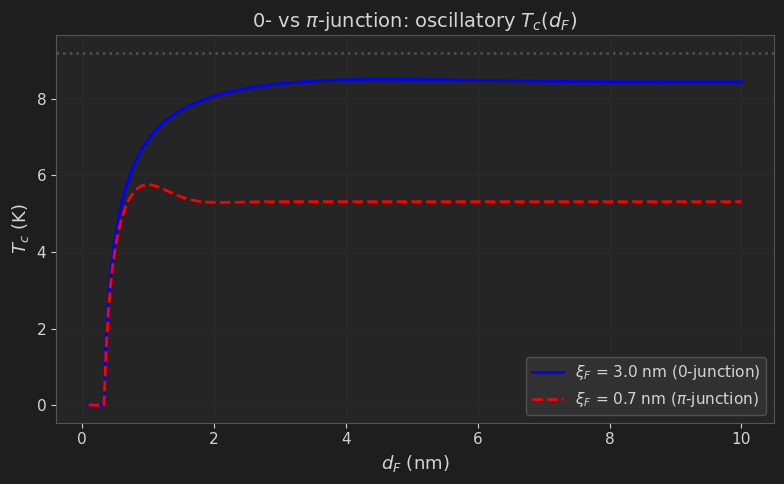

In [5]:
# 0-junction vs π-junction Tc comparison
import numpy as np, matplotlib.pyplot as plt
from supermag import critical_temperature

d_F = np.linspace(0.1, 10, 300)
params_0  = dict(Tc0=9.2, d_S=50.0, E_ex=256.0, xi_S=38.0, xi_F=3.0)   # large xi_F → 0-junction regime
params_pi = dict(Tc0=9.2, d_S=50.0, E_ex=256.0, xi_S=38.0, xi_F=0.7)   # small xi_F → π-junction regime

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_F, critical_temperature(d_F_array=d_F, **params_0),
        'b-', lw=2, label=rf'$\xi_F$ = 3.0 nm (0-junction)')
ax.plot(d_F, critical_temperature(d_F_array=d_F, **params_pi),
        'r--', lw=2, label=rf'$\xi_F$ = 0.7 nm ($\pi$-junction)')
ax.axhline(params_0['Tc0'], ls=':', color='grey', alpha=0.5)
ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title(r'0- vs $\pi$-junction: oscillatory $T_c(d_F)$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Interface transparency: the role of $\gamma_B$

The parameter $\gamma_B = R_B \mathcal{A} / \rho_F \xi_F$ encodes interface resistance.
Physically:

| $\gamma_B$ | Meaning | Effect on $T_c$ |
|:-----------:|:--------|:-----------------|
| 0 | Perfectly transparent | Maximum pair-breaking; deepest $T_c$ dip |
| $\sim 0.3$ | Moderate barrier | Reduced pair leakage; shallower oscillation |
| $\gg 1$ | Tunnel junction | Minimal proximity; $T_c \to T_{c0}$ |

The boundary condition at the S/F interface becomes

$$\xi_F \left.\frac{\partial F}{\partial x}\right|_{x=0} = \frac{1}{\gamma_B}\bigl(F_S - F_F\bigr),$$

interpolating between full continuity ($\gamma_B=0$) and complete decoupling ($\gamma_B\to\infty$).

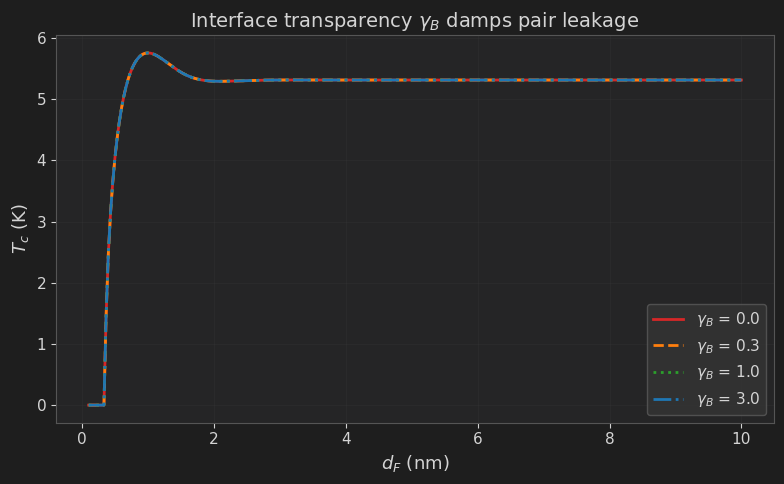

In [ ]:
# γ_B sweep: effect of interface transparency on Tc oscillations
import numpy as np, matplotlib.pyplot as plt
from supermag import critical_temperature

d_F = np.linspace(0.1, 10, 300)
base = dict(Tc0=9.2, d_S=50.0, E_ex=256.0, xi_S=38.0, xi_F=0.7, model="fominov")

fig, ax = plt.subplots(figsize=(8, 5))
for gamma_B, color, ls in [(0.0, '#d62728', '-'), (0.3, '#ff7f0e', '--'),
                             (1.0, '#2ca02c', ':'), (3.0, '#1f77b4', '-.')]:
    Tc = critical_temperature(d_F_array=d_F, gamma_B=gamma_B, **base)
    ax.plot(d_F, Tc, color=color, ls=ls, lw=2, label=rf'$\gamma_B$ = {gamma_B}')

ax.set_xlabel(r'$d_F$ (nm)', fontsize=13)
ax.set_ylabel(r'$T_c$ (K)', fontsize=13)
ax.set_title(r'Interface transparency $\gamma_B$ damps pair leakage', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Depairing channels

Pair-breaking in S/F bilayers has **four** physical origins, each computed
by a dedicated `supermag.depairing_*` function:

| Channel | Physical origin | Formula | API function |
|:--------|:----------------|:--------|:-------------|
| $\lambda_{\rm AG}$ | Spin-flip (Abrikosov–Gor'kov) | $\Gamma_s / 2k_BT$ | `depairing_ag()` |
| $\lambda_Z$ | Zeeman (Pauli paramagnetic) | $(\mu_B H)^2 / (2\pi k_BT)^2$ | `depairing_zeeman()` |
| $\lambda_{\rm orb}$ | Orbital (diamagnetic) | $D(eH)^2 d^2 / (3\hbar \cdot 2\pi k_BT)$ | `depairing_orbital_perp()` |
| $\lambda_{\rm SO}$ | Spin–orbit coupling | $\Gamma_{\rm so} / 2k_BT$ | `depairing_soc()` |

In the digamma formalism the total depairing is additive,
$$\lambda_{\rm dep} = \lambda_{\rm AG} + \lambda_Z + \lambda_{\rm orb} + \lambda_{\rm SO}$$
and enters the self-consistency equation through the digamma difference $\psi\!\bigl(\tfrac12 + \lambda_{\rm dep}\bigr) - \psi\!\bigl(\tfrac12\bigr)$.

The convenience function `depairing_from_physical()` computes all four channels
in a single call and returns a dict that can be passed directly to
`critical_temperature(depairing=...)`.

The left panel below shows the temperature dependence of each channel;
the right panel shows their cumulative effect on $T_c(d_F)$.


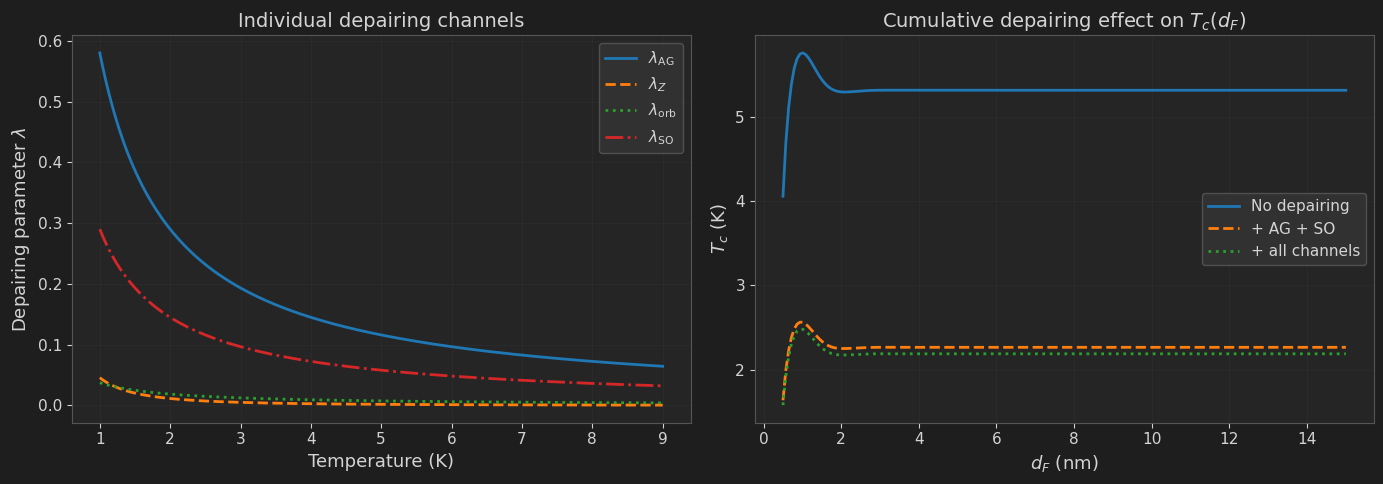

In [7]:
# Depairing channels: individual T-dependence + cumulative Tc effect
import numpy as np, matplotlib.pyplot as plt
import supermag

nb = supermag.get_material('Nb')
d_F = np.linspace(0.5, 15, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual depairing channels vs temperature
T_arr = np.linspace(1.0, 9.0, 200)
channels = [
    (lambda T: supermag.depairing_ag(0.1, T),
     r'$\lambda_{\rm AG}$', '#1f77b4', '-'),
    (lambda T: supermag.depairing_zeeman(2.0, T),
     r'$\lambda_Z$', '#ff7f0e', '--'),
    (lambda T: supermag.depairing_orbital_perp(4.0, 2.0, 50.0, T),
     r'$\lambda_{\rm orb}$', '#2ca02c', ':'),
    (lambda T: supermag.depairing_soc(0.05, T),
     r'$\lambda_{\rm SO}$', '#d62728', '-.'),
]
for fn, label, col, ls in channels:
    axes[0].plot(T_arr, [fn(T) for T in T_arr],
                 color=col, ls=ls, lw=2, label=label)

axes[0].set_xlabel('Temperature (K)', fontsize=13)
axes[0].set_ylabel(r'Depairing parameter $\lambda$', fontsize=13)
axes[0].set_title('Individual depairing channels', fontsize=14)
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

# Right: Tc(d_F) with cumulative depairing via the API
Tc_bare = supermag.critical_temperature(
    Tc0=nb['Tc'], d_S=50.0, d_F_array=d_F,
    E_ex=256.0, xi_S=nb['xi_S'], xi_F=0.7)

configs = [
    ('No depairing', None, '#1f77b4', '-'),
    ('+ AG + SO',
     dict(gamma_s_meV=0.1, H_tesla=0.0, D_nm2ps=0.0,
          thickness_nm=50.0, Gamma_so_meV=0.05, T_kelvin=5.0),
     '#ff7f0e', '--'),
    ('+ all channels',
     dict(gamma_s_meV=0.1, H_tesla=2.0, D_nm2ps=4.0,
          thickness_nm=50.0, Gamma_so_meV=0.05, T_kelvin=5.0),
     '#2ca02c', ':'),
]

for label, kw, col, ls in configs:
    if kw:
        dp = supermag.depairing_from_physical(**kw)
        Tc = supermag.critical_temperature(
            Tc0=nb['Tc'], d_S=50.0, d_F_array=d_F,
            E_ex=256.0, xi_S=nb['xi_S'], xi_F=0.7, depairing=dp)
    else:
        Tc = Tc_bare
    axes[1].plot(d_F, Tc, color=col, ls=ls, lw=2, label=label)

axes[1].set_xlabel(r'$d_F$ (nm)', fontsize=13)
axes[1].set_ylabel(r'$T_c$ (K)', fontsize=13)
axes[1].set_title(r'Cumulative depairing effect on $T_c(d_F)$', fontsize=14)
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

fig.tight_layout(); plt.show()


## Key Physics Summary

| Phenomenon | Origin | Observable |
|------------|--------|------------|
| Pair oscillation | Exchange-induced FFLO momentum | LDOS oscillation in STM |
| $T_c$ suppression | Pair leakage from S→F | Resistive transition |
| $T_c$ oscillation | Interference of reflected pairs | Non-monotonic $T_c(d_F)$ |
| Re-entrant SC | Destructive interference at specific $d_F$ | $T_c \to 0$ then recovery |
| $\pi$-state | Sign change of pair amplitude | Half-quantum flux in SQUIDs |

## References

1. Buzdin, A.I. et al., "Critical-current oscillations as a function of the exchange field and thickness of the ferromagnetic metal (F) in an S-F-S Josephson junction," JETP Lett. **35**, 178 (1982).
2. Radović, Z. et al., "Transition temperatures of superconductor-ferromagnet superlattices," Phys. Rev. B **44**, 759 (1991).
3. Fominov, Ya.V., Chtchelkatchev, N.M. & Golubov, A.A., "Nonmonotonic critical temperature in superconductor/ferromagnet bilayers," Phys. Rev. B **66**, 014507 (2002).
4. Buzdin, A.I., "Proximity effects in superconductor-ferromagnet heterostructures," Rev. Mod. Phys. **77**, 935 (2005).